In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter('ignore')

SEED = 30

In [2]:
df_test = pd.read_csv("/kaggle/input/playground-series-s5e6/test.csv")
df_train = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")
df_original = pd.read_csv("/kaggle/input/fertilizer-prediction/Fertilizer Prediction.csv")

df_train = pd.concat([df_train, df_original], axis=0).reset_index(drop=True)

In [3]:
def mapk(actual, predicted, k=3):
    total_score = 0.0
    actual = le.inverse_transform(actual)
    for a, p in zip(actual, predicted):
        if a in p[:k]:
            index = p.index(a)
            total_score += 1.0 / (index + 1)
    return total_score / len(actual)

## Feature Engineering

In [4]:
df_train.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0.0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1.0,27,69,65,Sandy,Millets,30,6,18,28-28
2,2.0,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3.0,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4.0,35,58,43,Red,Paddy,37,2,16,DAP


In [5]:
le = LabelEncoder()
le.fit(df_train['Fertilizer Name'])

AGGREGATES = ['mean']
FEATURES = ['Temparature', 'Humidity', 'Moisture', 'Soil Type',
            'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous']

def make_log(df, features=FEATURES):
    """
    Makes log transformations for all features in features
    """
    df_temp = df.copy()
    features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    for feature in features:
        df_temp[f'{feature}_log'] = np.log1p(df_temp[feature])
    return df_temp

def make_interactions(df, features=FEATURES):
    """
    Makes interactions between all features listed in features
    """
    df_temp = df.copy()
    cat_cols = list(df_temp[features].select_dtypes(include=['category']).columns)
    num_features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    df_temp2 = pd.get_dummies(df_temp, columns=cat_cols)
    cat_features = list(df_temp2.select_dtypes(include=['bool']).columns)
    features = num_features + cat_features

    for i in range(len(features) - 1):
        for j in range(i, len(features) - 1):
            df_temp[f'{features[i]}_{features[j]}'] = df_temp2[features[i]] * df_temp2[features[j]]

    return df_temp

def make_polynomials(df, features=FEATURES):
    """
    Make polynomial of features listed in features
    Only does 2nd and 3rd power for now
    """
    df_temp = df.copy()
    num_features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    for feature in num_features:
        df_temp[f'{feature}2'] = df_temp[feature] ** 2
        df_temp[f'{feature}3'] = df_temp[feature] ** 3

    return df_temp

def make_aggregates(df, features=FEATURES):
    """
    Makes aggregates of features listed in features using the formula
    new_feature = X - aggregate_type(df.groupby(Y)[X])
    - where X is a numerical feature and Y is a categorical feature
    - chosen aggregates are set in AGGREGATES
    """
    df_temp = df.copy()
    num_cols = list(df[features].select_dtypes(include=['int64', 'float64']).columns)
    cat_cols = list(df[features].select_dtypes(include=['category']).columns)

    for cat_col in cat_cols:
        for agg_type in AGGREGATES:
            aggs = df_temp[num_cols] - df_temp.groupby(cat_col)[num_cols].transform(agg_type)
            aggs.columns  = [f"{cat_col}_{num_col}_{agg_type}" for num_col in aggs.columns]
            df_temp = pd.concat([df_temp, aggs], axis=1)
    return df_temp

def make_features(df, test=False):
    df_temp = df.copy()
    df_temp.drop(columns=['id'], inplace=True)
    cat_cols = df_temp.select_dtypes(include=['object']).columns
    df_temp[cat_cols] = df_temp[cat_cols].astype('category')

    if not test:
        df_temp['Fertilizer Name'] = le.transform(df_temp['Fertilizer Name'])

    # df_temp = make_log(df_temp)
    # df_temp = make_interactions(df_temp)
    # df_temp = make_polynomials(df_temp)
    # df_temp = make_aggregates(df_temp)
    
    return df_temp

In [6]:
df_train1 = make_features(df_train)

In [7]:
initial_params = {
    "tree_method": "gpu_hist",
    "predictor": "gpu_predictor",
    'seed': SEED,
    'enable_categorical': True,
    'early_stopping_rounds': 100
}

In [8]:
X = df_train1.drop(columns=['Fertilizer Name'])
y = df_train1['Fertilizer Name']

In [9]:
def cross_val(X, y, params=initial_params, K=10, debug=True):
    kf = KFold(n_splits=K, shuffle=True, random_state=SEED)
    fold_scores = []
    fold = 0

    for train_idx, val_idx in kf.split(X):
        fold += 1
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(
            **params
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        val_pred = model.predict_proba(X_val_fold)
        val_pred = np.argsort(val_pred, axis=1)[:, -3:][:, ::-1]
        val_pred = [[le.classes_[j] for j in row] for row in val_pred]

        score = mapk(y_val_fold, val_pred)
        fold_scores.append(score)
        if debug == True:
            print(f'Fold {fold} Mean Average Precision Score: {score}')

    avg_score = np.mean(fold_scores)
    if debug == True:
        print(f'Average Validation Fold Score: {avg_score}')
    return avg_score

In [10]:
xgb_params1 = {
    'learning_rate': 0.03,
     'max_depth': 12,
     'subsample': 0.30000000000000004,
     'colsample_bytree': 0.30000000000000004,
     'max_bin': 926, 
     'min_child_weight': 6,
     'gamma': 0.1,
     'lambda': 1.8875729586599337,
     'alpha': 0.004494936589076713,
     'max_delta_step': 1,
    'n_estimators': 3000,
    'enable_categorical': True,
    'early_stopping_rounds': 100,
    'random_state': SEED,
    'tree_method': 'gpu_hist',
    'preditor': 'gpu_predictor'
}

xgb_params2 = {'learning_rate': 0.03,
               'max_depth': 11,
               'subsample': 0.8,
               'colsample_bytree': 0.30000000000000004,
               'max_bin': 1551,
               'min_child_weight': 3,
               'gamma': 0.0,
               'lambda': 0.0013312723042592412,
               'alpha': 0.6136573473631746,
               'max_delta_step': 8,
               'n_estimators': 3000,
               'enable_categorical': True,
               'early_stopping_rounds': 100,
               'random_state': SEED,
               'tree_method': 'gpu_hist',
               'preditor': 'gpu_predictor'
              }

# this stuff from https://www.kaggle.com/code/pirhosseinlou/xgboost-single-model-v2
xgb_params3 = {
        'objective': 'multi:softprob',
        'num_class': 7,
        'max_depth': 12,
        'learning_rate': 0.02,
        'n_estimators': 100_000,
        'reg_alpha': 3,
        'reg_lambda': 1.4,
        'gamma': 0.26,
        'max_delta_step': 5,
        'subsample': 0.86,
        'colsample_bytree': 0.4,
        'min_child_weight': 5,
        'random_state': 42,
        'n_jobs': -1,
        'early_stopping_rounds': 30,
        'eval_metric': 'mlogloss',
        'enable_categorical': True,
        'device': "cuda"
    }

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=SEED)

In [12]:
K = 10
kf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

base_models = [
    XGBClassifier(**xgb_params1),
    XGBClassifier(**xgb_params2),
    XGBClassifier(**xgb_params3)
             ]
N_MODELS = len(base_models)
NUM_CLASSES = 7

oof_train = np.zeros((len(X_train), N_MODELS * NUM_CLASSES))
val_preds = np.zeros((len(X_val), N_MODELS * NUM_CLASSES))

for m_idx, model in enumerate(base_models):
    val_fold_preds = []
    scores = []
    fold = 0
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        fold += 1

        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)

        # Predict on validation fold and store in OOF matrix
        probas = model.predict_proba(X_v)
        oof_train[val_idx, m_idx*NUM_CLASSES:(m_idx+1)*NUM_CLASSES] = probas

        # Predict on test data and save for averaging
        val_pred = model.predict_proba(X_val)
        val_fold_preds.append(val_pred)
        val_pred = np.argsort(val_pred, axis=1)[:, -3:][:, ::-1]
        val_pred = [[le.classes_[j] for j in row] for row in val_pred]
        score = mapk(y_val, val_pred)
        scores.append(score)
        print(f"XGB Model {m_idx+1} fold {fold} val score: {score}")

    avg_score = np.mean(scores)
    print(f"========== XGB Model {m_idx+1} Average Val Score: {avg_score} ==========")
    print('\n')
    val_preds[:, m_idx*NUM_CLASSES:(m_idx+1)*NUM_CLASSES] = np.mean(val_fold_preds, axis=0)

XGB Model 1 fold 1 val score: 0.36510588235287295
XGB Model 1 fold 2 val score: 0.36448039215679345
XGB Model 1 fold 3 val score: 0.36513137254895206
XGB Model 1 fold 4 val score: 0.3655647058822868
XGB Model 1 fold 5 val score: 0.364729411764638
XGB Model 1 fold 6 val score: 0.36525098039208814
XGB Model 1 fold 7 val score: 0.3642235294116974
XGB Model 1 fold 8 val score: 0.3648117647058147
XGB Model 1 fold 9 val score: 0.3650803921567958
XGB Model 1 fold 10 val score: 0.3644372549018926
========== XGB Model 1 Average Val Score: 0.3648815686273832 ==========


XGB Model 2 fold 1 val score: 0.3655941176469904
XGB Model 2 fold 2 val score: 0.3647647058822837
XGB Model 2 fold 3 val score: 0.3650843137254227
XGB Model 2 fold 4 val score: 0.3648411764705211
XGB Model 2 fold 5 val score: 0.3654196078430695
XGB Model 2 fold 6 val score: 0.36530784313718706
XGB Model 2 fold 7 val score: 0.3640078431371864
XGB Model 2 fold 8 val score: 0.3647176470587547
XGB Model 2 fold 9 val score: 0.3645980

In [13]:
np.save('oof_train.npy', oof_train)
np.save('val_preds.npy', val_preds)

## Shoving Stuff into Meta Model

In [14]:
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [16]:
class mapk_loss_criterion(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_actual, k=3):
        topk_preds = torch.topk(y_pred, k, dim=1).indices
        y_actual = y_actual.view(-1, 1).expand_as(topk_preds)
    
        correct = (topk_preds == y_actual).float()

        precision_at_k = correct / (torch.arange(1, k+1, device=y_pred.device).float())
        ap = precision_at_k * correct
    
        return ap.sum(dim=1).mean().item()

class MetaNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(N_MODELS * NUM_CLASSES, 32),
            nn.ReLU(),
            nn.Linear(32, 7)
        )

    def forward(self, X):
        return self.layers(X)

In [17]:
LEARNING_RATE = 1e-3
BATCH=64
EPOCHS=100

mapk_loss = mapk_loss_criterion()

In [18]:
oof_train = torch.tensor(oof_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
val_preds = torch.tensor(val_preds, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device).squeeze().long()

dataset = TensorDataset(oof_train, y_train_tensor)
loader = DataLoader(dataset, batch_size = BATCH)

In [19]:
all_train_ce_loss = []
all_train_mapk_loss = []
all_val_ce_loss = []
all_val_mapk_loss = []

torch.manual_seed(SEED)

meta_model = MetaNN().to(device)

criterion = nn.CrossEntropyLoss() # not using map@3 since not differentiable
optimizer = optim.Adam(meta_model.parameters(), lr=LEARNING_RATE)

for epoch in tqdm(range(EPOCHS)):
    meta_model.train()
    epoch_ce_loss = 0 # cross entropy loss
    epoch_mapk_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze().long()
        optimizer.zero_grad()
    
        logits = meta_model(X_batch)
        loss = criterion(logits, y_batch)
        epoch_ce_loss += loss.item()

        y_probs = torch.softmax(logits, dim=1)
        batch_mapk_loss = mapk_loss(y_probs, y_batch)
        epoch_mapk_loss += batch_mapk_loss
        
        loss.backward()
        optimizer.step()
    
    # validation
    epoch_ce_loss /= len(loader)
    epoch_mapk_loss /= len(loader)
    all_train_ce_loss.append(epoch_ce_loss)
    all_train_mapk_loss.append(epoch_mapk_loss)
    meta_model.eval()
    with torch.no_grad():
        logits = meta_model(val_preds)
        val_ce_loss = criterion(logits, y_val_tensor)
        all_val_ce_loss.append(val_ce_loss.item())

        y_probs = torch.softmax(logits, dim=1)
        val_mapk_loss = mapk_loss(y_probs, y_val_tensor)
        all_val_mapk_loss.append(val_mapk_loss)
        

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"========== EPOCH :{epoch} ==========")
        print(f"Training Cross Entropy Loss: {epoch_ce_loss}")
        print(f"Training MAP@3 Loss: {epoch_mapk_loss}")
        print(f"Validation Cross Entropy Loss: {val_ce_loss}")
        print(f"Validation MAP@3 Loss: {val_mapk_loss}")

  1%|          | 1/100 [00:23<38:01, 23.05s/it]

========== EPOCH :0 ==========
Training Cross Entropy Loss: 1.8918346907156296
Training MAP@3 Loss: 0.36504954104267356
Validation Cross Entropy Loss: 1.8876731395721436
Validation MAP@3 Loss: 0.3680450916290283


 25%|██▌       | 25/100 [09:15<27:40, 22.14s/it]

========== EPOCH :24 ==========
Training Cross Entropy Loss: 1.8853164895813024
Training MAP@3 Loss: 0.37038270177521276
Validation Cross Entropy Loss: 1.8863402605056763
Validation MAP@3 Loss: 0.3685862720012665


 50%|█████     | 50/100 [18:31<18:35, 22.30s/it]

========== EPOCH :49 ==========
Training Cross Entropy Loss: 1.8851453188731357
Training MAP@3 Loss: 0.3705005583462257
Validation Cross Entropy Loss: 1.8860371112823486
Validation MAP@3 Loss: 0.36914899945259094


 75%|███████▌  | 75/100 [27:47<09:16, 22.25s/it]

========== EPOCH :74 ==========
Training Cross Entropy Loss: 1.8850204403312265
Training MAP@3 Loss: 0.37069880071593025
Validation Cross Entropy Loss: 1.8857665061950684
Validation MAP@3 Loss: 0.36939606070518494


100%|██████████| 100/100 [37:03<00:00, 22.23s/it]

========== EPOCH :99 ==========
Training Cross Entropy Loss: 1.884957268562368
Training MAP@3 Loss: 0.3706151466665209
Validation Cross Entropy Loss: 1.8856768608093262
Validation MAP@3 Loss: 0.3696039021015167


In [20]:
torch.save(meta_model, 'meta_model.pth')

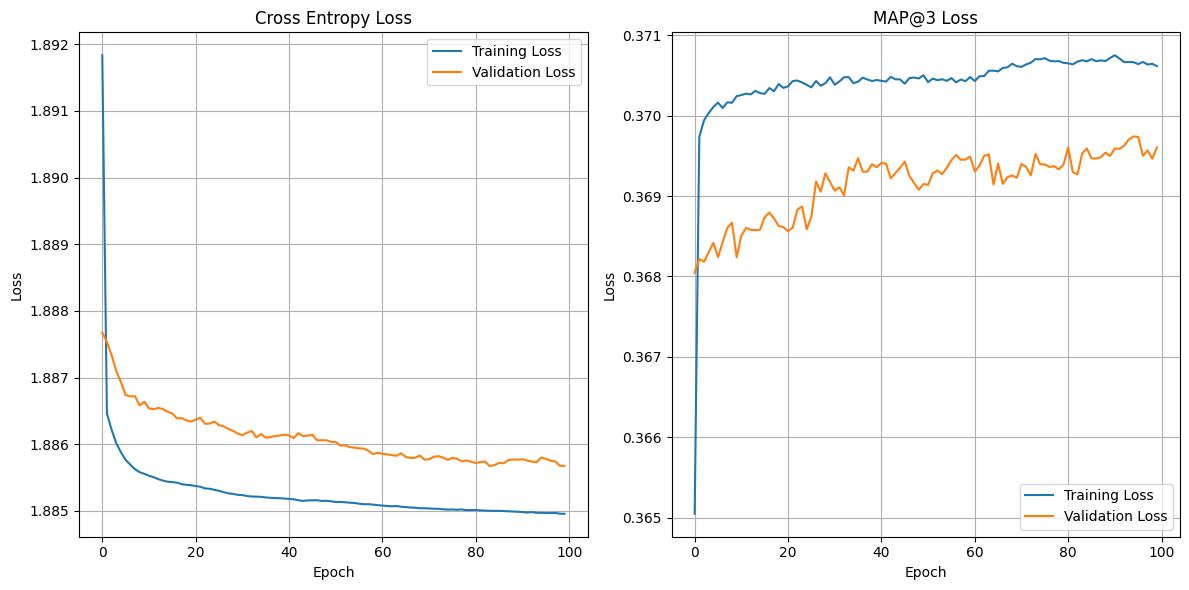

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

axes[0].plot(all_train_ce_loss, label='Training Loss')
axes[0].plot(all_val_ce_loss, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(all_train_mapk_loss, label='Training Loss')
axes[1].plot(all_val_mapk_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('MAP@3 Loss')
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

## Submission

In [22]:
df_test1 = make_features(df_test, test=True)
# df_test1 = torch.tensor(df_test1.values, dtype=torch.float32)
# df_test1 = df_test1.to(device)

In [23]:
model1 = XGBClassifier(**xgb_params1)
model2 = XGBClassifier(**xgb_params2)
model3 = XGBClassifier(**xgb_params3)

model1.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
model2.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
model3.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

test_preds = np.zeros((len(df_test1), N_MODELS * NUM_CLASSES))
test_preds[:, 0 * NUM_CLASSES:1*NUM_CLASSES] = model1.predict_proba(df_test1)
test_preds[:, 1 * NUM_CLASSES:2*NUM_CLASSES] = model2.predict_proba(df_test1)
test_preds[:, 2 * NUM_CLASSES:3*NUM_CLASSES] = model3.predict_proba(df_test1)

In [24]:
# y_test_pred = meta_model.predict_proba(test_preds)
test_preds_tensor = torch.tensor(test_preds, dtype=torch.float32).to(device)
logits = meta_model(test_preds_tensor)
y_test_pred = torch.softmax(logits, dim=1)
y_test_pred = y_test_pred.cpu().detach().numpy()
y_test_pred = np.argsort(y_test_pred, axis=1)[:, -3:][:, ::-1]
y_test_pred = [[le.classes_[j] for j in row] for row in y_test_pred]
y_test_pred = [' '.join(row) for row in y_test_pred]

submission = pd.read_csv("/kaggle/input/playground-series-s5e6/sample_submission.csv")
submission['Fertilizer Name'] = y_test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,Fertilizer Name
0,750000,10-26-26 20-20 DAP
1,750001,17-17-17 10-26-26 Urea
2,750002,20-20 28-28 17-17-17
3,750003,14-35-14 DAP 10-26-26
4,750004,20-20 Urea 10-26-26
